<div align="center">
  <img src="assets/title.png" width="1200">
</div>

# Quantum Variational Circuits: 2-Pixel Line Detection

## 🎯 What You'll Learn
In this workshop, we will tackle a fundamental computer vision problem using a Variational Quantum Classifier (VQC). 

By the end of this hands-on workshop, you will:

* ✅ Understand basic quantum computing concepts (qubits, gates, circuits)
* ✅ Build a Quantum Neural Network (QNN) from scratch
* ✅ Train your QNN to classify 2-pixel line patterns
* ✅ Visualize and interpret quantum machine learning results

## ⚠️ Disclaimer & Goals

This session is not designed to master all QML concepts in 45 minutes. Instead, our goal is to provide a **practical overview** and a **launchpad for your quantum journey**, demonstrating that "quantum" is happening right now.

### How to Use This Notebook

**A Starting Point:** Think of this as a live roadmap rather than a textbook.

**Learn at Your Own Pace:** You are encouraged to use this notebook for continued study after the session.

**Deep Dives:** Throughout the notebook, you will find **📚 Advanced Sections** containing extra topics and technical deep-dives. These didn't fit into our 45-minute window, but they are there for you to explore independently when you're ready to level up.

---

## 🌌 Quantum Computing Basics

### Qubits: The Building Blocks

**Classical bit:** Either 0 OR 1 (like a light switch)

**Qubit:** Can be 0 AND 1 simultaneously (**superposition**)

**Mathematical representation:**
$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle = \begin{bmatrix} \alpha \\ \beta \end{bmatrix}$$

Where $|\alpha|^2$ = probability of measuring 0, $|\beta|^2$ = probability of measuring 1.

**Example:** $|\psi\rangle = 0.8|0\rangle + 0.6|1\rangle = \begin{bmatrix} 0.8 \\ 0.6 \end{bmatrix}$ → 64% chance of |0⟩, 36% chance of |1⟩


---

### Quantum Gates: Operations on Qubits

Quantum gates transform qubit states (like rotations):

**Single-Qubit Gates:**

- **RX(θ), RY(θ), RZ(θ)** — Rotation gates (trainable parameters in QNNs)
- **H (Hadamard)** — Creates equal superposition: $|0\rangle \rightarrow \frac{|0\rangle + |1\rangle}{\sqrt{2}}$
- **X, Y, Z (Pauli)** — Bit flips and phase shifts

**Two-Qubit Gate:**

- **CNOT** — Creates entanglement between qubits
  - If control = |1⟩ → flip target
  - If control = |0⟩ → do nothing

💡 Entanglement - a connection between two qubits where measuring one immediately reveals information about the other, no matter the distance, because their states are fundamentally linked.

---

### Quantum Circuit Example

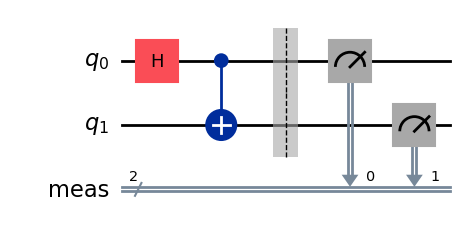

In [1]:
from qiskit import QuantumCircuit

# Create a simple 2-qubit circuit
qc = QuantumCircuit(2)
qc.h(0)           # Hadamard on qubit 0
qc.cx(0, 1)       # CNOT: control=0, target=1
qc.measure_all()  # Measure both qubits

# Visualize
qc.draw('mpl')

---

##  ⚛ Moving to Quantum Machine Learning

### The QML Workflow: From Circuit to Result
1. **Data Encoding & Circuit Design:** Map classical datasets into quantum feature maps and construct a parameterized circuit.
2. **Hardware Tailoring:** Transpile and compile the abstract circuit to match the specific connectivity, gate set, and noise profile of the target quantum processor.
3. **Training & Inference:** Use Qiskit Runtime Primitives to execute iterative training loops and perform final model inference for prediction generation.
4. **Analysis & Evaluation:** Post-process the output data to visualize loss curves and calculate final classification accuracy to determine model performance.


<div align="center">
  <img src="assets/qml_workflow.png" width="800">
</div>

### 🎨 The Challenge

We will train our quantum model to differentiate between two types of features on a $2 \times 4$ pixel grid:
* **Horizontal Lines:** A row of 2 illuminated pixels.
* **Vertical Lines:** A column of 2 illuminated pixels.

Crucially, both shapes contain exactly the same amount of "light" (2 pixels), and they can appear anywhere on the grid. The quantum computer cannot simply memorize pixel locations or measure total brightness; it must learn the spatial correlation of the shapes themselves.

## Data generation

#### We define a dataset where 2-pixel lines can appear in any valid position on the $2 \times 4$ grid. We also add background noise to make the classification a true machine learning challenge.

In [2]:
# Standard library imports
import os
import copy
from dotenv import load_dotenv

# Third-party imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import XGate, z_feature_map
from qiskit.primitives import BaseEstimatorV2, StatevectorEstimator as Estimator
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info.operators.base_operator import BaseOperator
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import (
    ALAPScheduleAnalysis,
    ConstrainedReschedule,
    PadDynamicalDecoupling,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

print("✅ All imports loaded successfully")


✅ All imports loaded successfully


In [3]:
# Dataset Configuration
size = 8  # Total pixels per image (will be encoded as qubits)
vert_size = 2  # Image height in pixels
hor_size = round(size / vert_size)  # Image width (4 pixels)
line_size = 2  # Length of lines to detect

def generate_dataset(num_images):

    images = []
    labels = []
    
    # Pre-calculate all possible line positions
    hor_array = np.zeros((size - (line_size - 1) * vert_size, size))
    ver_array = np.zeros((round(size / vert_size) * (vert_size - line_size + 1), size))

    # Generate horizontal line templates
    j = 0
    for i in range(0, size - 1):
        if i % (size / vert_size) <= (size / vert_size) - line_size:
            for p in range(0, line_size):
                hor_array[j][i + p] = np.pi / 2
            j += 1

    # Generate vertical line templates
    j = 0
    for i in range(0, round(size / vert_size) * (vert_size - line_size + 1)):
        for p in range(0, line_size):
            ver_array[j][i + p * round(size / vert_size)] = np.pi / 2
        j += 1

    # Create random images
    for n in range(num_images):
        rng = np.random.randint(0, 2)
        if rng == 0:
            labels.append(-1)  # Horizontal
            random_image = np.random.randint(0, len(hor_array))
            images.append(np.array(hor_array[random_image]))
        elif rng == 1:
            labels.append(1)  # Vertical
            random_image = np.random.randint(0, len(ver_array))
            images.append(np.array(ver_array[random_image]))

        # Add noise to background pixels
        for i in range(size):
            if images[-1][i] == 0:
                images[-1][i] = np.random.rand() * np.pi / 4
                
    return np.array(images), labels

# Generate 200 images and split 70/30 train/test
np.random.seed(42)
images, labels = generate_dataset(200)
train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.3, random_state=246
)


#### Plot the images

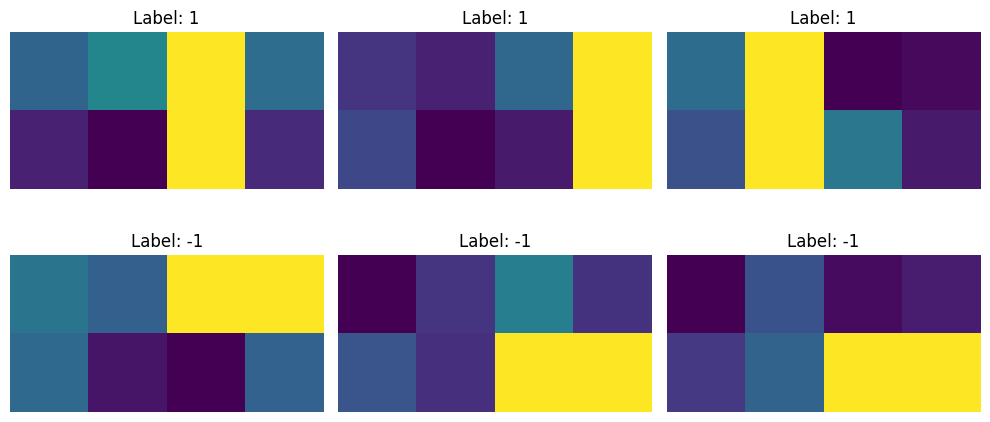

In [4]:
fig, ax = plt.subplots(2, 3, figsize=(10, 5))

# Convert labels to numpy array if needed
train_labels_array = np.array(train_labels)

# Get indices for each label
label_1_indices = np.where(train_labels_array == 1)[0]
label_minus1_indices = np.where(train_labels_array == -1)[0]

# First row: 3 random samples with label 1 (vertical)
for i in range(3):
    idx = np.random.choice(label_1_indices)
    ax[0, i].imshow(train_images[idx].reshape(vert_size, hor_size), cmap='viridis')
    ax[0, i].set_title(f"Label: {train_labels[idx]}")
    ax[0, i].axis('off')

# Second row: 3 random samples with label -1 (horizontal)
for i in range(3):
    idx = np.random.choice(label_minus1_indices)
    ax[1, i].imshow(train_images[idx].reshape(vert_size, hor_size), cmap='viridis')
    ax[1, i].set_title(f"Label: {train_labels[idx]}")
    ax[1, i].axis('off')

plt.tight_layout()
plt.show()


## 1. **Data Encoding & Circuit Design:**

#### To bridge the gap between classical data and quantum computation, we define a function $f_{\theta}(\vec{x})$ that processes an input vector $\vec{x}$ (like image pixels) to produce a classification label. This is the heart of a Variational Quantum Circuit (VQC).

<div align="center">
  <img src="assets/qml_formula.png" width="600">
</div>


#### Think of this process as a three-stage quantum pipeline:

**The Feature Map $U(\vec{x})$:** This "loads" your classical data into quantum states. By applying data-dependent rotations, we move from a simple $|0\rangle$ state into a complex high-dimensional Hilbert space where patterns might be easier to separate.

**The Ansatz $W(\theta)$:** This is the "brain" of your circuit. It consists of tunable quantum gates (parameters $\theta$) that we adjust—much like weights in a classical neural network—to find the optimal transformation for our specific task.

**The Observable $O$:** Finally, we perform a measurement. By calculating the expectation value of an operator $O$, we collapse the quantum information back into a classical number that tells us whether the result is a $+1$ or a $-1$.

<details>
<summary>📚 <b>Advanced: Understanding the Dagger (†) Operator</b></summary>

In our QNN formula:

$$f_\theta(\vec{x}) = \langle 0 | U^\dagger(\vec{x}) \, W^\dagger(\theta) \, O \, W(\theta) \, U(\vec{x}) | 0 \rangle$$

The **† (dagger)** represents the **conjugate transpose** of a quantum operation—essentially running the circuit backwards.

### Why Do We Need It?

**The Sandwich Structure:** Notice how the formula "sandwiches" the observable $O$ between forward operations $W(\theta)U(\vec{x})$ and their daggers $U^\dagger(\vec{x})W^\dagger(\theta)$.

This creates a **unitary transformation** that:

1. **Encodes data** → $U(\vec{x})|0\rangle$
2. **Applies learning** → $W(\theta)$
3. **Measures in transformed basis** → $O$
4. **Reverses transformation** → $W^\dagger(\theta)U^\dagger(\vec{x})$

### The Key Insight

Without the dagger operations, we'd just be measuring in the computational basis. The sandwich structure lets us measure **how much the circuit changed the state** relative to the starting point—this is what gives us the prediction!

**Think of it as:** Forward → Measure → Rewind = "How far did we travel?"

**Deep dive:** [IBM Quantum - Unitary Operations](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/multiple-systems/quantum-information#unitary-operations)

</details>


#### Now, we need to address a fundamental challenge:  
A quantum computer cannot "see" classical data. It doesn't understand pixels, spreadsheets, or raw numbers in their native format. To a quantum processor, your image is just a collection of classical bits, but it needs to work with quantum states.
This is where **Data Encoding** steps in. It acts as the translator that "uploads" your classical vector $\vec{x}$ into the vast, high-dimensional Hilbert space of the qubits.
In this workshop, we use the [**Z Feature Map**](https://quantum.cloud.ibm.com/learning/en/courses/quantum-machine-learning/data-encoding#z-feature-map) to perform this translation. Each feature in your input vector is encoded as a rotation on a qubit around the Z-axis, so the number of qubits determines how many features we can encode at once. For our dataset, one qubit per feature is sufficient, which keeps the circuit simple and efficient while capturing all the information we need for learning.

advanced section to learn another data encoding methods reffering to this source https://quantum.cloud.ibm.com/learning/en/courses/quantum-machine-learning/data-encoding 

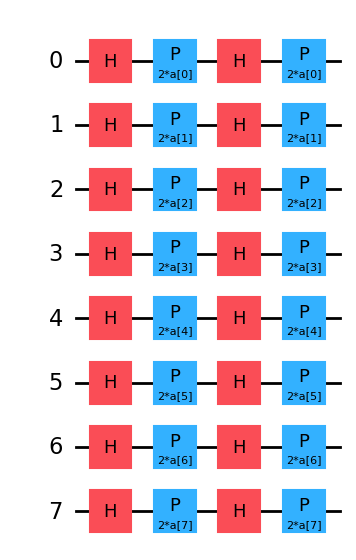

In [5]:
from qiskit.circuit.library import z_feature_map

# One qubit per data feature
num_qubits = len(train_images[0])

# Data encoding
# Note that qiskit orders parameters alphabetically. We assign the parameter prefix "a" to ensure our data encoding goes to the first part of the circuit, the feature mapping.
feature_map = z_feature_map(num_qubits, parameter_prefix="a")
feature_map.draw(output='mpl')

## Choosing an Ansatz ⚛

Now that our data is encoded into a quantum state, we need a way to **process and learn from it**.

This is where the **Ansatz** comes in.

The Ansatz is a parameterized quantum circuit with tunable parameters $\theta$ (like weights in a neural network).

In this workshop, we use:

- **Rotation gates (RY, RX)** — they "rotate" the qubit state, changing its value in a controllable way (this is how we introduce learnable parameters). For now, you can think of this step simply as an operation that adjusts the qubit based on $\theta$.  
- **CNOT gates** — they connect qubits together, allowing them to share information. For now, think of this as an operation that lets qubits influence each other.
- 
Together, these let the circuit learn patterns in the data.

---

💡 When choosing an ansatz:

- keep it **simple** (hardware is noisy)  
  Quantum computers are error-prone, so deeper circuits (especially with many two-qubit gates) can quickly degrade results. Simpler circuits are usually more reliable.

- match the **problem structure**  
  Try to design the circuit in a way that reflects your data. For example, for images, it makes sense to connect **neighboring qubits**, since nearby pixels are often related.

- avoid too many **parameters**  
  More parameters give more flexibility, but also make training slower and harder. A smaller, well-structured ansatz is often easier to optimize.

Let’s build it 👇

3
2+ qubit depth: 1

📊 Entanglement Pattern Visualization:
Image Layout (2×4 pixels = 8 qubits):
  Top row:    [Q0] [Q1] [Q2] [Q3]
               ↓    ↓    ↓    ↓
  Bottom row: [Q4] [Q5] [Q6] [Q7]

CNOT Connections (↓ indicates entanglement):
  Column 0: Q0 ↓ Q4
  Column 1: Q1 ↓ Q5
  Column 2: Q2 ↓ Q6
  Column 3: Q3 ↓ Q7

✓ Vertical neighbors are entangled (between rows)
✗ No horizontal entanglement within rows


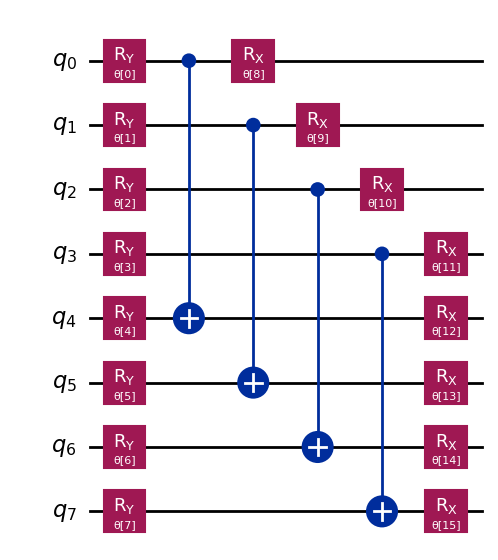

In [6]:
# Import the necessary packages
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

# Initialize the circuit using the same number of qubits as the image has pixels
qnn_circuit = QuantumCircuit(size)

# We choose to have two variational parameters for each qubit.
params = ParameterVector("θ", length=2 * size)

# A first variational layer:
for i in range(size):
    qnn_circuit.ry(params[i], i)

# Entanglement pattern: Connect VERTICALLY adjacent qubits between rows
# Image structure:  [0][1][2][3]  ← Top row (qubits 0-3)
#                    ↓  ↓  ↓  ↓
#                   [4][5][6][7]  ← Bottom row (qubits 4-7)
# 
# CNOTs create "communication" between pixels in the same column,
# allowing the circuit to detect VERTICAL line patterns.
qnn_cnot_list = [[0, 4], [1, 5], [2, 6], [3, 7]]

for i in range(len(qnn_cnot_list)):
    qnn_circuit.cx(qnn_cnot_list[i][0], qnn_cnot_list[i][1])

# The second variational layer:
for i in range(size):
    qnn_circuit.rx(params[size + i], i)

# Check the circuit depth, and the two-qubit gate depth
print(qnn_circuit.decompose().depth())
print(
    f"2+ qubit depth: {qnn_circuit.decompose().depth(lambda instr: len(instr.qubits) > 1)}"
)

# Visualize the entanglement pattern
print("\n📊 Entanglement Pattern Visualization:")
print("=" * 50)
print("Image Layout (2×4 pixels = 8 qubits):")
print("  Top row:    [Q0] [Q1] [Q2] [Q3]")
print("               ↓    ↓    ↓    ↓")
print("  Bottom row: [Q4] [Q5] [Q6] [Q7]")
print("\nCNOT Connections (↓ indicates entanglement):")
print("  Column 0: Q0 ↓ Q4")
print("  Column 1: Q1 ↓ Q5")
print("  Column 2: Q2 ↓ Q6")
print("  Column 3: Q3 ↓ Q7")
print("\n✓ Vertical neighbors are entangled (between rows)")
print("✗ No horizontal entanglement within rows")
print("=" * 50)

# Draw the circuit
qnn_circuit.draw("mpl")


## Building the Full Quantum Model

Now we combine everything together.

We take:
- the **feature map $U(\vec{x})$** (data encoding)  
- the **ansatz $W(\theta)$** (trainable circuit)  

and stack them into a single quantum circuit.

This is very similar to a neural network:
- input layer → $U(\vec{x})$  
- trainable layers → $W(\theta)$  

Together, they form our **Quantum Neural Network (QNN)**.

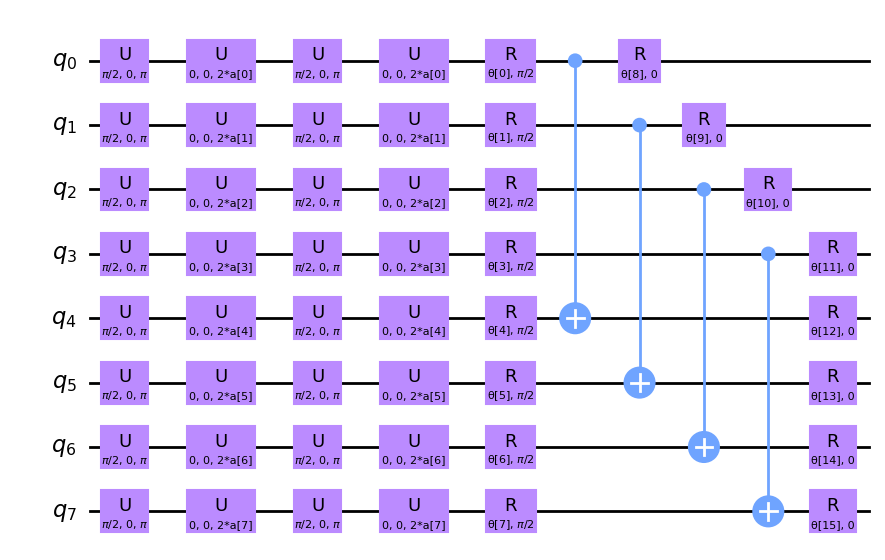

In [7]:
# QNN ansatz
ansatz = qnn_circuit

# Combine the feature map with the ansatz
full_circuit = QuantumCircuit(num_qubits)
full_circuit.compose(feature_map, range(num_qubits), inplace=True)
full_circuit.compose(ansatz, range(num_qubits), inplace=True)

# Display the circuit
full_circuit.decompose().draw("mpl", style="clifford", fold=-1)

## 🎉 Congratulations!

You’ve just built your **Variational Quantum Circuit (VQC)**!  

But don’t think that’s the end - this is only the **model structure**. Next, we need to prepare the code to **train the VQC and make it learn from our data**, so it can actually start solving the task.

### Defining the Observable 🧭

Next, we define an **observable**, which is an operator we can measure on the quantum circuit to get a classical number. Here, we use a `Z` operator on each qubit. Technically, this means we are measuring in the [Pauli Z basis]('https://quantum.cloud.ibm.com/learning/en/courses/foundations-of-quantum-error-correction/stabilizer-formalism/pauli-operations-and-observables'), which gives eigenvalues of +1 or -1. For our binary classification task, each qubit carries information about the input, and measuring all of them produces a value we can feed into the cost function to guide training.

In [8]:
from qiskit.quantum_info import SparsePauliOp

observable = SparsePauliOp.from_list([("Z" * (num_qubits), 1)])

Before we can train our quantum neural network, we need a way to get outputs from the circuit. That’s what the **forward pass** does.  

The function takes `input_params` and `weight_params` separately. The `input_params` represent the data we want to encode, like image pixels, and the `weight_params` are the tunable parameters of the ansatz that will be optimized.  

In [9]:
from qiskit.primitives import BaseEstimatorV2
from qiskit.quantum_info.operators.base_operator import BaseOperator


def forward(
    circuit: QuantumCircuit,
    input_params: np.ndarray,
    weight_params: np.ndarray,
    estimator: BaseEstimatorV2,
    observable: BaseOperator,
) -> np.ndarray:
    """
    Forward pass of the neural network.

    Args:
        circuit: circuit consisting of data loader gates and the neural network ansatz.
        input_params: data encoding parameters.
        weight_params: neural network ansatz parameters.
        estimator: EstimatorV2 primitive.
        observable: a single observable to compute the expectation over.

    Returns:
        expectation_values: an array (for one observable) or a matrix (for a sequence of observables) of expectation values.
        Rows correspond to observables and columns to data samples.
    """
    num_samples = input_params.shape[0]
    weights = np.broadcast_to(weight_params, (num_samples, len(weight_params)))
    params = np.concatenate((input_params, weights), axis=1)
    pub = (circuit, observable, params)
    job = estimator.run([pub])
    result = job.result()[0]
    expectation_values = result.data.evs

    return expectation_values

### How does our QNN learn? 🤔

Now we bring in classical methods. To train our model, we need a **loss function** that tells us how well the QNN is performing.

The loss function compares the predicted labels from our model with the true labels and measures the difference between them. In our case, we use **Mean Squared Error (MSE)**, which simply computes the average of the squared differences.

There are many possible loss functions, but MSE is a simple and effective choice for our example.

In [10]:
def mse_loss(predict: np.ndarray, target: np.ndarray) -> np.ndarray:
    """
    Mean squared error (MSE).

    prediction: predictions from the forward pass of neural network.
    target: true labels.

    output: MSE loss.
    """
    if len(predict.shape) <= 1:
        return ((predict - target) ** 2).mean()
    else:
        raise AssertionError("input should be 1d-array")

Now we define a slightly different version of the loss function that depends only on the **trainable parameters** (weights). This is the function the classical optimizer will use during training.

Instead of passing all inputs every time, we fix the data and other components, and only vary the `weight_params`. For each set of weights, the function runs a forward pass, computes the loss, and returns a single value representing how well the model is performing.

The optimizer will repeatedly call this function, trying different values of the weights and gradually minimizing the loss.

In [11]:
def mse_loss_weights(weight_params: np.ndarray) -> np.ndarray:
    """
    Cost function for the optimizer to update the ansatz parameters.

    weight_params: ansatz parameters to be updated by the optimizer.

    output: MSE loss.
    """
    predictions = forward(
        circuit=circuit,
        input_params=input_params,
        weight_params=weight_params,
        estimator=estimator,
        observable=observable,
    )

    cost = mse_loss(predict=predictions, target=target)
    objective_func_vals.append(cost)

    global iter
    if iter % 50 == 0:
        print(f"Iter: {iter}, loss: {cost}")
    iter += 1

    return cost

---

## Qiskit Patterns Step 2: Optimize problem for quantum execution
**Note:** In this workshop, we'll use a **local simulator** for training our quantum neural network. This approach offers several advantages:

✅ **Instant results** - No queue waiting time  
✅ **Perfect accuracy** - Ideal for learning quantum concepts  
✅ **No API setup required** - Get started immediately  
✅ **Reproducible results** - Consistent behavior for debugging

**Why simulation for training?**

Training quantum neural networks on real hardware is **not recommended** because:
- ⏱️ **Time-consuming**: Each training iteration requires multiple circuit executions, leading to hours of queue time
- 💰 **Resource-intensive**: Uses significant quantum computing credits
- 🎲 **Noisy results**: Hardware noise can interfere with gradient-based optimization
- 🔄 **Impractical**: Modern QML research uses simulation for training, then validates on hardware
  
**Want to try real quantum hardware?** 

After completing the main workshop, check out the **Bonus Section** at the end where you'll:
- Run a single trained model inference on real IBM quantum hardware
- Compare simulator vs. hardware results
- Learn about quantum noise and decoherence effects
---
### Setting Up the Simulator
We'll use Qiskit's `StatevectorEstimator` for fast, accurate simulation:


Then open .env and paste your API key:
IBM_QUANTUM_API_KEY=your_api_key_here

We will set some initial global variables for the cost function.

In [12]:
# Globals
circuit = full_circuit
observables = observable
# input_params = train_images_batch
# target = train_labels_batch
objective_func_vals = []
iter = 0

## Qiskit Patterns Step 3: Execute using Qiskit Primitives

### Looping Over the Dataset: Batches and Epochs 🌀

Now we’re ready to **train our quantum neural network**. We go through the dataset in small batches and repeat this process over a number of epochs.  

For each batch, we select a subset of images and their labels. The images are encoded into the circuit as `input_params`, and the labels become the `target`. Then, a classical optimizer (COBYLA) updates the ansatz parameters (`weight_params`) by minimizing the loss function.  

In [13]:
from qiskit.primitives import StatevectorEstimator as Estimator
from scipy.optimize import minimize

batch_size = 140
num_epochs = 1
num_samples = len(train_images)

# Globals
circuit = full_circuit
estimator = Estimator()  # simulator for debugging
observables = observable
objective_func_vals = []
iter = 0

# Random initial weights for the ansatz
np.random.seed(42)
weight_params = np.random.rand(len(ansatz.parameters)) * 2 * np.pi

for epoch in range(num_epochs):
    for i in range((num_samples - 1) // batch_size + 1):
        print(f"Epoch: {epoch}, batch: {i}")
        start_i = i * batch_size
        end_i = start_i + batch_size
        train_images_batch = np.array(train_images[start_i:end_i])
        train_labels_batch = np.array(train_labels[start_i:end_i])
        input_params = train_images_batch
        target = train_labels_batch
        iter = 0
        res = minimize(
            mse_loss_weights, weight_params, method="COBYLA", options={"maxiter": 100}
        )
        weight_params = res["x"]

Epoch: 0, batch: 0
Iter: 0, loss: 0.9991069567281223
Iter: 50, loss: 0.8588455897289666


---

## Qiskit Patterns Step 4: Post-process Results 📊

### Testing and Accuracy

Now that training is complete, it’s time to **see how well our model actually performs**.

We evaluate the trained QNN on the training dataset by comparing its predictions to the true labels. This gives us a sense of how accurately the model has learned the patterns in the data.

Let’s compute the training accuracy 👇

In [14]:
import copy
from sklearn.metrics import accuracy_score
from qiskit.primitives import StatevectorEstimator as Estimator  # simulator
# from qiskit_ibm_runtime import EstimatorV2 as Estimator  # real quantum computer

estimator = Estimator()
# estimator = Estimator(backend=backend)

pred_train = forward(circuit, np.array(train_images), res["x"], estimator, observable)
# pred_train = forward(circuit_ibm, np.array(train_images), res['x'], estimator, observable_ibm)

print(pred_train)

pred_train_labels = copy.deepcopy(pred_train)
pred_train_labels[pred_train_labels >= 0] = 1
pred_train_labels[pred_train_labels < 0] = -1
print(pred_train_labels)
print(train_labels)

accuracy = accuracy_score(train_labels, pred_train_labels)
print(f"Train accuracy: {accuracy * 100}%")

[ 0.49725565  0.1280899   0.1892073   0.48699257 -0.59508509  0.36321981
  0.28195686  0.25791848 -0.46594329  0.53064591  0.29964644  0.37649409
 -0.30453693 -0.49278203 -0.10487423 -0.47208327 -0.30067461 -0.21311639
 -0.2376223  -0.52274596  0.70448834 -0.21153465  0.13429805  0.41808028
 -0.25233338  0.35312331  0.19295018  0.63640429  0.57817847 -0.06462914
  0.27273645  0.27464106 -0.26917179  0.52294464  0.43312426 -0.55631856
  0.12105059  0.61151595 -0.39250887 -0.31749372 -0.12454554  0.38193249
 -0.57648116 -0.58264229  0.28470183 -0.10147245  0.15969571  0.39246205
 -0.43694346  0.17419279 -0.35388548  0.12738581  0.26575166 -0.08482755
  0.17843013  0.50651623  0.40504429  0.67402233 -0.27020008 -0.43935395
 -0.16292336 -0.6271395   0.61371194 -0.16422455  0.41232734  0.31644624
  0.57413452 -0.19320912 -0.2324908   0.52107403  0.68270621 -0.6046445
  0.33453114  0.47831013 -0.30480936 -0.15049796  0.46510654 -0.22118408
  0.23384983  0.28297285  0.57612509  0.18989629  0.

The training accuracy comes out to **100%**, which shows that our quantum neural network has successfully learned to classify the training data!  

This is an excellent result. Now let's check the test set to see how well the model generalizes to unseen data.

In [15]:
pred_test = forward(circuit, np.array(test_images), res["x"], estimator, observable)
# pred_test = forward(circuit_ibm, np.array(test_images), res['x'], estimator, observable_ibm)

print(pred_test)

pred_test_labels = copy.deepcopy(pred_test)
pred_test_labels[pred_test_labels >= 0] = 1
pred_test_labels[pred_test_labels < 0] = -1
print(pred_test_labels)
print(test_labels)

accuracy = accuracy_score(test_labels, pred_test_labels)
print(f"Test accuracy: {accuracy * 100}%")

[-0.57992705 -0.35144735  0.0970567   0.4631878  -0.45301402 -0.40893017
  0.61372541 -0.15548885  0.1143847  -0.55333792  0.62839737  0.13722235
  0.5312776   0.53804905 -0.15677229  0.68551261 -0.46637339  0.19617312
  0.51477248  0.57698111  0.34024116 -0.52203654 -0.09801071  0.49391063
  0.53541851 -0.38269089  0.40451851  0.36775684  0.22896399 -0.14228781
  0.30675934 -0.64224509 -0.21360573  0.27783513  0.63230751  0.64786479
 -0.05655753  0.47273299  0.23292388 -0.61991812 -0.22684667 -0.44006395
  0.63058624  0.57698259  0.57071945 -0.14364586  0.61046347  0.64766511
  0.2027517   0.25428567 -0.38061181 -0.53617807  0.24266538  0.59152047
  0.64007662  0.51625703  0.20949302  0.51740581 -0.22238132 -0.42251365]
[-1. -1.  1.  1. -1. -1.  1. -1.  1. -1.  1.  1.  1.  1. -1.  1. -1.  1.
  1.  1.  1. -1. -1.  1.  1. -1.  1.  1.  1. -1.  1. -1. -1.  1.  1.  1.
 -1.  1.  1. -1. -1. -1.  1.  1.  1. -1.  1.  1.  1.  1. -1. -1.  1.  1.
  1.  1.  1.  1. -1. -1.]
[-1, -1, 1, 1, -1, -1, 1

Excellent! The model achieves **100% accuracy on the test set** as well, demonstrating perfect generalization.

This outstanding result shows that:

- Our quantum circuit architecture (ansatz) is well-suited for this classification task
- The training process successfully optimized the parameters
- The model learned meaningful patterns rather than just memorizing the training data

Let's visualize the loss curve to confirm that the optimization converged properly.

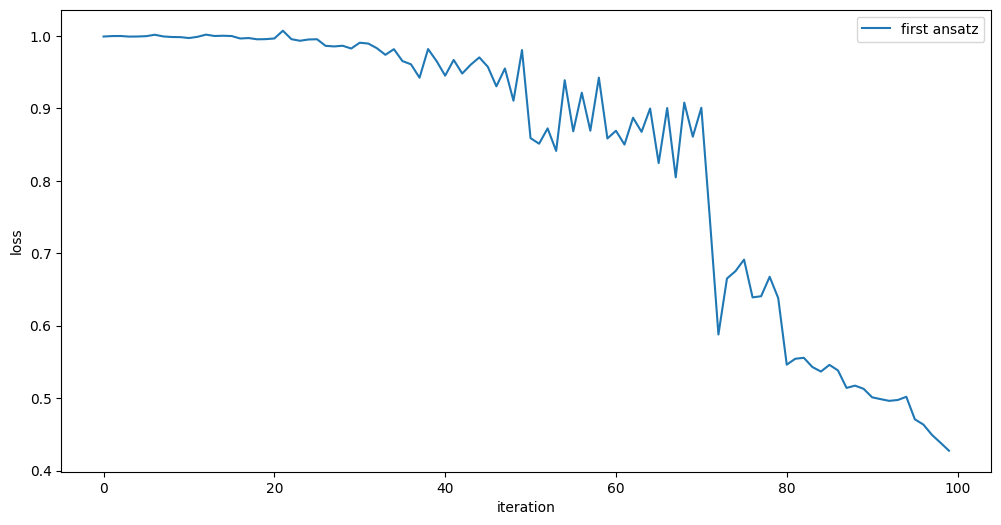

In [16]:
obj_func_vals_first = objective_func_vals
# import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(obj_func_vals_first, label="first ansatz")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.legend()
plt.show()

The loss curve shows steady convergence, confirming that the optimizer successfully found a good solution. The stable plateau at the end indicates that the training process reached an optimal state.

With 100% accuracy on both training and test sets, our quantum neural network has successfully solved this binary classification problem!

#### As we can see, the quantum variational circuit performs quite well on this simple dataset. While this is a basic example, it's an excellent starting point for understanding quantum machine learning. Quantum algorithms have the potential to outperform or enhance existing classical approaches, especially as quantum hardware continues to improve. This is just the beginning of your quantum journey - there's so much more to explore!

---


## 🚀 Bonus Section: Testing on Real Quantum Hardware
Now that you've successfully trained your quantum neural network using simulation, let's test it on **actual quantum hardware**!
### ⚠️ Important Notes
**Why we don't train on hardware:**
- Training requires hundreds of circuit executions per iteration
- Each execution involves queue waiting time (minutes to hours)
- Hardware noise can disrupt gradient-based optimization
- A full training run could take days and consume significant quantum credits
**What we'll do instead:**
- Use our **already-trained weights** from simulation
- Run **inference on a single test image**
- Compare **simulator vs. hardware results**
- Observe **real quantum noise effects**
This is the standard approach in quantum machine learning research!
---
### Step 1: Set Up IBM Quantum Access
To run on real quantum hardware, you'll need an **IBM Quantum API key**.
#### Get Your API Key:
1. Go to [IBM Quantum Platform](https://quantum.cloud.ibm.com/)
2. Create a free account (if you don't have one)
3. Navigate to your account settings
4. Copy your API key
💡 **Free tier includes 10 minutes of quantum hardware access** - perfect for this experiment!
#### Store Your API Key Securely:
First, create a `.env` file from the template:


In [17]:
# Uncomment to create .env file
# !cp .env.example .env


Then open `.env` and paste your API key:
```
IBM_QUANTUM_API_KEY=your_api_key_here
```


In [18]:
# Load API key from .env file
load_dotenv()
api_key = os.getenv("IBM_QUANTUM_API_KEY")
# Save account credentials
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=api_key,
    overwrite=True
)
print("✅ IBM Quantum account configured successfully!")


✅ IBM Quantum account configured successfully!


---
### Step 2: Select a Quantum Backend
We'll use the **least busy** available quantum computer to minimize wait time:


In [19]:
from qiskit_ibm_runtime import QiskitRuntimeService
# Connect to IBM Quantum
service = QiskitRuntimeService()
# Get the least busy real quantum backend
backend = service.least_busy(operational=True, simulator=False)
print(f"Selected backend: {backend.name}")
print(f"Number of qubits: {backend.num_qubits}")
print(f"Pending jobs: {backend.status().pending_jobs}")


qiskit_runtime_service.__init__:WARNING:2026-04-07 09:24:29,705: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-07 09:24:30,513: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-07 09:24:32,703: Using instance: open-instance, plan: open


Selected backend: ibm_fez
Number of qubits: 156
Pending jobs: 0


---
### Step 3: Transpile Circuit for Hardware
Real quantum computers have specific constraints (qubit connectivity, gate sets, etc.). We need to **transpile** our circuit to match the hardware:


In [20]:
# Get hardware-specific information
target = backend.target
# Create a pass manager for optimization
pm = generate_preset_pass_manager(target=target, optimization_level=3)
# Transpile our circuit for the selected backend
circuit_ibm = pm.run(full_circuit)
observable_ibm = observable.apply_layout(circuit_ibm.layout)
print(f"Original circuit depth: {full_circuit.depth()}")
print(f"Transpiled circuit depth: {circuit_ibm.depth()}")
print(f"✅ Circuit optimized for {backend.name}")


Original circuit depth: 7
Transpiled circuit depth: 16
✅ Circuit optimized for ibm_fez


---
### Step 4: Run Single-Image Inference
Now let's test our trained model on **one test image** using real quantum hardware:


In [22]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit.primitives import StatevectorEstimator
import numpy as np
# Select a single test image
test_idx = 0
single_test_image = np.array([test_images[test_idx]])
true_label = test_labels[test_idx]
print(f"Testing image {test_idx}")
print(f"True label: {true_label}")
print(f"Image features: {single_test_image[0]}")
# Run inference on SIMULATOR (for comparison)
estimator_sim = StatevectorEstimator()
pred_sim = forward(full_circuit, single_test_image, res["x"], estimator_sim, observable)
pred_label_sim = 1 if pred_sim[0] >= 0 else -1
print(f"\n📊 Simulator prediction: {pred_sim[0]:.4f} → Label: {pred_label_sim}")
# Run inference on HARDWARE
print(f"\n⏳ Submitting job to {backend.name}...")
print("This may take a few minutes depending on queue...")
estimator_hardware = Estimator(mode=backend)
pred_hw = forward(circuit_ibm, single_test_image, res["x"], estimator_hardware, observable_ibm)
pred_label_hw = 1 if pred_hw[0] >= 0 else -1
print(f"\n🔬 Hardware prediction: {pred_hw[0]:.4f} → Label: {pred_label_hw}")


Testing image 0
True label: -1
Image features: [0.62103252 0.25034763 0.49157394 0.6958453  1.57079633 1.57079633
 0.48369782 0.18296594]

📊 Simulator prediction: -0.5799 → Label: -1

⏳ Submitting job to ibm_fez...
This may take a few minutes depending on queue...

🔬 Hardware prediction: -0.5679 → Label: -1


---
### Step 5: Compare Results
Let's analyze the difference between simulator and hardware:



📊 RESULTS COMPARISON
True Label:           -1
Simulator Prediction: -1 (raw: -0.5799)
Hardware Prediction:  -1 (raw: -0.5679)
Absolute Difference:  0.0120
Relative Noise:       2.07%
✅ Both simulator and hardware predicted correctly!


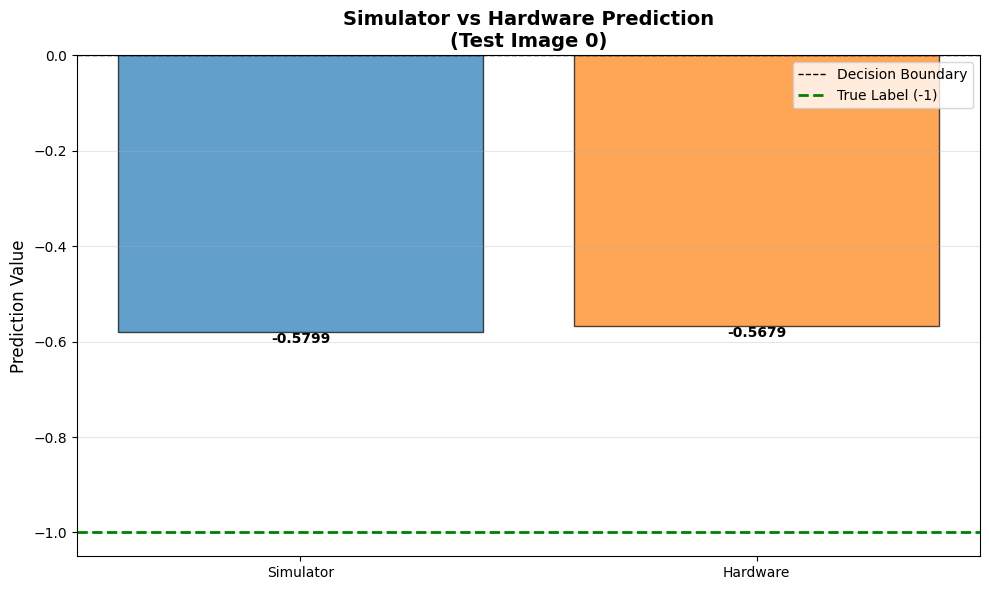

In [23]:
import matplotlib.pyplot as plt
# Calculate prediction difference
difference = abs(pred_sim[0] - pred_hw[0])
noise_level = (difference / abs(pred_sim[0])) * 100 if pred_sim[0] != 0 else 0
print("\n" + "="*50)
print("📊 RESULTS COMPARISON")
print("="*50)
print(f"True Label:           {true_label}")
print(f"Simulator Prediction: {pred_label_sim} (raw: {pred_sim[0]:.4f})")
print(f"Hardware Prediction:  {pred_label_hw} (raw: {pred_hw[0]:.4f})")
print(f"Absolute Difference:  {difference:.4f}")
print(f"Relative Noise:       {noise_level:.2f}%")
print("="*50)
if pred_label_sim == pred_label_hw == true_label:
    print("✅ Both simulator and hardware predicted correctly!")
elif pred_label_sim == true_label and pred_label_hw != true_label:
    print("⚠️ Hardware prediction affected by quantum noise")
elif pred_label_sim != true_label:
    print("❌ Model prediction error (not hardware noise)")
# Visualize comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
predictions = ['Simulator', 'Hardware']
values = [pred_sim[0], pred_hw[0]]
colors = ['#1f77b4', '#ff7f0e']
bars = ax.bar(predictions, values, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, label='Decision Boundary')
ax.axhline(y=true_label, color='green', linestyle='--', linewidth=2, label=f'True Label ({true_label})')
ax.set_ylabel('Prediction Value', fontsize=12)
ax.set_title(f'Simulator vs Hardware Prediction\n(Test Image {test_idx})', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}',
            ha='center', va='bottom' if height > 0 else 'top',
            fontweight='bold')
plt.tight_layout()
plt.show()


---
### 🎓 What You Learned
**Key Insights:**
1. **Quantum Noise is Real**: Hardware predictions differ from perfect simulation due to:
   - Decoherence (qubits losing quantum state)
   - Gate errors (imperfect quantum operations)
   - Measurement errors (readout mistakes)
2. **Practical QML Workflow**:
   - ✅ Train on simulator (fast, accurate)
   - ✅ Validate on hardware (realistic performance)
   - ✅ This is how real quantum ML research works!
3. **Hardware Limitations**:
   - Current quantum computers are "NISQ" (Noisy Intermediate-Scale Quantum)
   - Noise increases with circuit depth
   - Error mitigation techniques can help
**Next Steps:**
- Try testing multiple images to see noise variability
- Experiment with different backends
- Explore error mitigation techniques
- Learn about quantum error correction
---
### 🔗 Additional Resources
- [IBM Quantum Documentation](https://docs.quantum.ibm.com/)
- [Qiskit Runtime Primitives](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime)
- [Error Mitigation Guide](https://docs.quantum.ibm.com/guides/error-mitigation-and-suppression-techniques)
- [Quantum Hardware Specifications](https://quantum.cloud.ibm.com/services/resources)
---


### **Continue Your Quantum Journey:**

1. **Explore More Quantum Topics**
   -  [Basics of quantum information](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information)
   -  [Quantum algorithms](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms)
   -  [Quantum error correction](https://quantum.cloud.ibm.com/learning/en/courses/foundations-of-quantum-error-correction)

2. **Hands-On Practice**
   - Design your own [quantum circuit using composer](https://quantum.cloud.ibm.com/composer)
   - Experiment with different gate combinations
   - Run circuits on real quantum hardware

3. **Join the Community**
   - Participate in quantum computing forums
   - Contribute to open-source quantum projects
   - Attend quantum computing meetups and conferences

--- 
### 💬 Connect with Us

- 🔗 [Artem Konotopchyk on LinkedIn](https://www.linkedin.com/in/artem-konotopchyk/)
- 🔗 [Manta Ribkauskytė on LinkedIn](https://www.linkedin.com/in/manta-ribkauskyt%C4%97-49927b29a/)
